In [1]:
# Installing required libraries
!pip -q install xgboost lightgbm

## Importing Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    silhouette_score
)

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    MiniBatchKMeans
)

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Loading the Dataset


In [3]:
def load_data():

    possible_paths = [
        '/content/Country-data.csv',
        'Country-data.csv',
        '/content/archive.zip',
        'archive.zip'
    ]

    for path in possible_paths:

        p = Path(path)

        if p.exists() and p.suffix.lower() == '.csv':
            return pd.read_csv(p)

        if p.exists() and p.suffix.lower() == '.zip':

            with zipfile.ZipFile(p, 'r') as z:

                for file_name in z.namelist():

                    if file_name.lower().endswith('.csv'):
                        return pd.read_csv(z.open(file_name))

    raise FileNotFoundError('Dataset not found')

df = load_data()

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Data Cleaning

In [4]:
df.columns = df.columns.str.strip().str.lower()
df = df.drop_duplicates().reset_index(drop=True)
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')
print(df.isnull().sum())
df = df.fillna(df.median(numeric_only=True))
print("\nFinal Dataset Shape:", df.shape)

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Final Dataset Shape: (167, 10)


# Exploratory Data Analysis (EDA)


In [5]:
# summary statistics
df.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


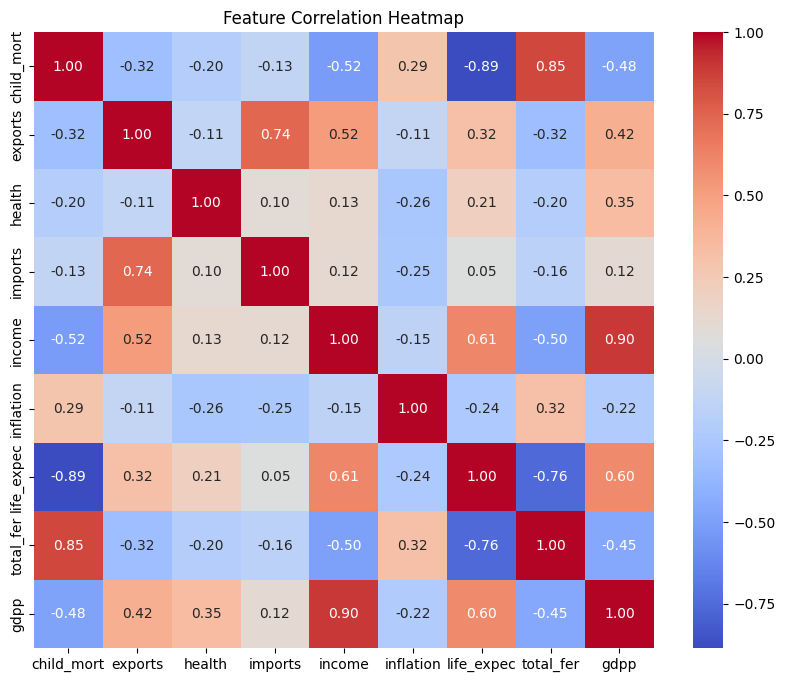

In [6]:
# correlation heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop(columns=['country']).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [7]:
# features most correlated with GDP per capita

gdp_corr = (
    df.drop(columns=['country'])
    .corr(numeric_only=True)['gdpp']
    .sort_values(ascending=False)
)

print(gdp_corr)

gdpp          1.000000
income        0.895571
life_expec    0.600089
exports       0.418725
health        0.345966
imports       0.115498
inflation    -0.221631
total_fer    -0.454910
child_mort   -0.483032
Name: gdpp, dtype: float64


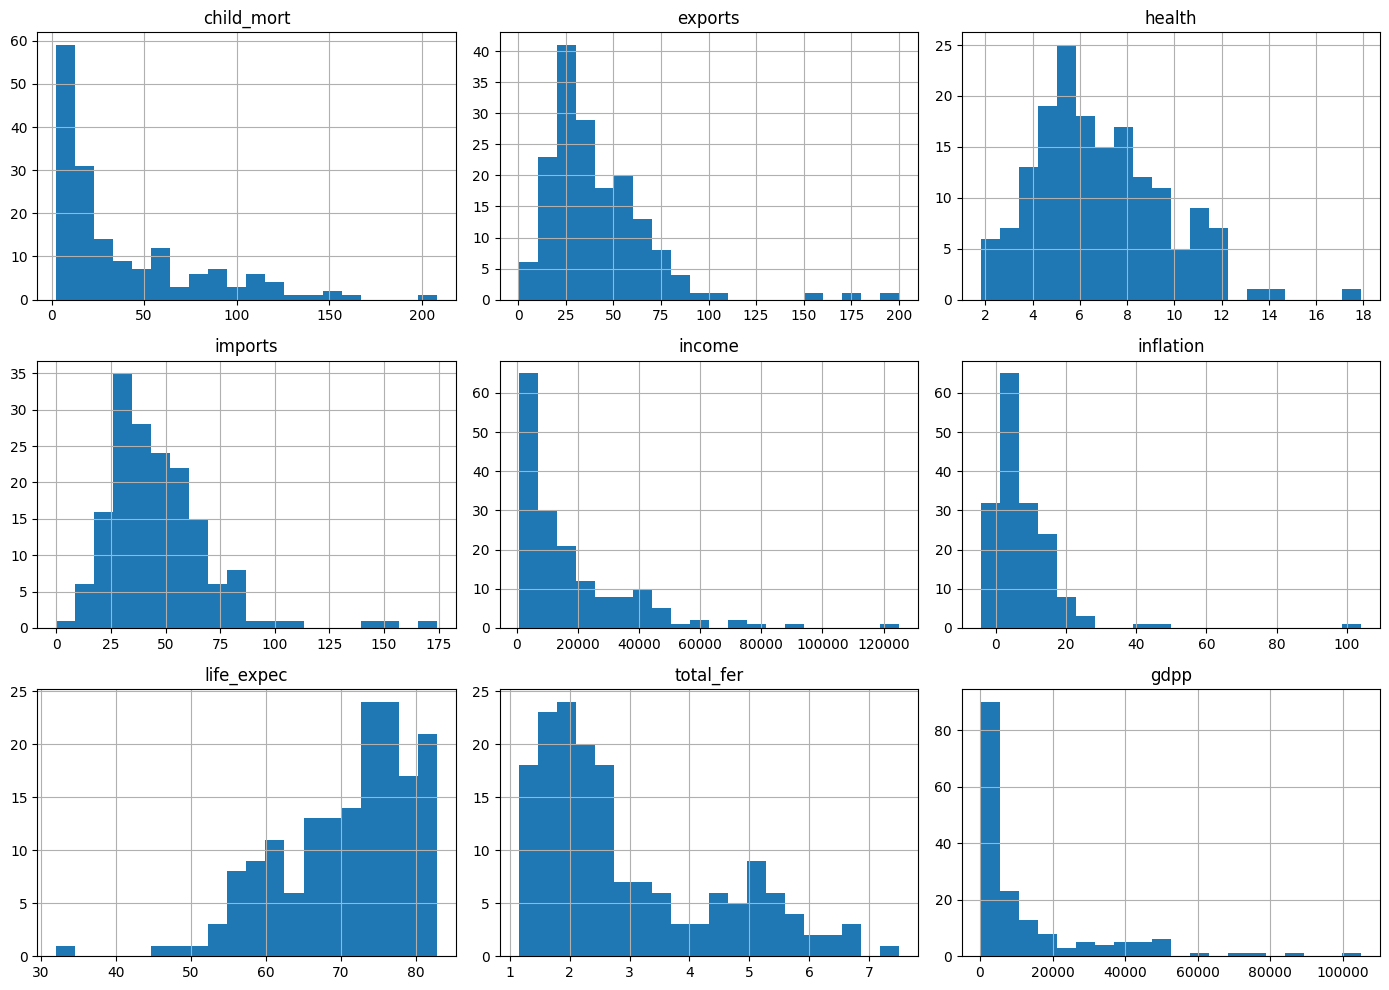

In [8]:
# distribution plots

df.drop(columns=['country']).hist(
    figsize=(14,10),
    bins=20
)

plt.tight_layout()
plt.show()

# Feature Scaling


In [9]:
X = df.drop(columns=['country']).astype('float32')

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Data Shape:", X_scaled.shape)

Scaled Data Shape: (167, 9)


# K-Means Clustering


In [10]:
scores = []

for k in range(2, 7):

    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        batch_size=32,
        n_init=10,
        max_iter=100
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append((k, score))

scores_df = pd.DataFrame(
    scores,
    columns=['k', 'silhouette_score']
)

scores_df

,k,silhouette_score
0,2,0.288880
1,3,0.295176
2,4,0.285132
3,5,0.288024
4,6,0.185307


In [11]:
best_k = scores_df.sort_values(
    'silhouette_score',
    ascending=False
).iloc[0]['k']

print("Best K Selected:", best_k)

kmeans = KMeans(
    n_clusters=int(best_k),
    random_state=RANDOM_STATE,
    n_init=20
)

cluster_labels = kmeans.fit_predict(X_scaled)

df['cluster'] = cluster_labels

df['cluster'].value_counts()

Best K Selected: 3.0


,count
cluster,
2,84
1,47
0,36


## Cluster Profiling


In [12]:
cluster_profile = (
    df.groupby('cluster')
    .agg({
        'child_mort':'mean',
        'income':'mean',
        'life_expec':'mean',
        'total_fer':'mean',
        'gdpp':'mean'
    })
    .round(2)
)

cluster_profile

,child_mort,income,life_expec,total_fer,gdpp
cluster,,,,,
0,5.00,45672.22,80.13,1.75,42494.44
1,92.96,3942.40,59.19,5.01,1922.38
2,21.93,12305.60,72.81,2.31,6486.45


# DBSCAN Clustering

In [13]:
dbscan = DBSCAN(
    eps=1.0,
    min_samples=5,
    n_jobs=-1
)

db_labels = dbscan.fit_predict(X_scaled)

print("Unique Labels:", np.unique(db_labels))
print("Noise Points:", np.sum(db_labels == -1))

Unique Labels: [-1  0  1  2]
Noise Points: 94


# Feature Selection

In [14]:
y = cluster_labels

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

feature_selector_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced_subsample'
)

feature_selector_model.fit(X_train, y_train)

selector = SelectFromModel(
    feature_selector_model,
    threshold='median',
    prefit=True
)

selected_features = X.columns[selector.get_support()].tolist()

print("Selected Features:")
print(selected_features)

Selected Features:
['child_mort', 'income', 'life_expec', 'total_fer', 'gdpp']


In [15]:
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)


# Model Training


In [16]:
results = []

In [17]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=6,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train_selected, y_train)

rf_predictions = rf_model.predict(X_test_selected)

results.append([
    'Random Forest',
    accuracy_score(y_test, rf_predictions),
    f1_score(y_test, rf_predictions, average='macro')
])

print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



In [18]:
# AdaBoost

try:

    ada_model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=2,
            random_state=RANDOM_STATE
        ),
        n_estimators=100,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    )

except:

    ada_model = AdaBoostClassifier(
        base_estimator=DecisionTreeClassifier(
            max_depth=2,
            random_state=RANDOM_STATE
        ),
        n_estimators=100,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    )

ada_model.fit(X_train_selected, y_train)

ada_predictions = ada_model.predict(X_test_selected)

results.append([
    'AdaBoost',
    accuracy_score(y_test, ada_predictions),
    f1_score(y_test, ada_predictions, average='macro')
])

print(classification_report(y_test, ada_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



In [19]:
# XGBoost with early stopping style regularization

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=2,
    tree_method='hist'
)

xgb_model.fit(
    X_train_selected,
    y_train,
    eval_set=[(X_test_selected, y_test)],
    verbose=False
)

xgb_predictions = xgb_model.predict(X_test_selected)

results.append([
    'XGBoost',
    accuracy_score(y_test, xgb_predictions),
    f1_score(y_test, xgb_predictions, average='macro')
])

print(classification_report(y_test, xgb_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



In [20]:
# LightGBM

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=2,
    verbose=-1
)

lgbm_model.fit(
    X_train_selected,
    y_train
)

lgbm_predictions = lgbm_model.predict(X_test_selected)

results.append([
    'LightGBM',
    accuracy_score(y_test, lgbm_predictions),
    f1_score(y_test, lgbm_predictions, average='macro')
])

print(classification_report(y_test, lgbm_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



# Model Comparison


In [21]:
results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'Macro_F1']
)

results_df.sort_values(
    by=['Macro_F1', 'Accuracy'],
    ascending=False
)


,Model,Accuracy,Macro_F1
3,LightGBM,1.000000,1.000000
0,Random Forest,0.970588,0.972932
1,AdaBoost,0.970588,0.972932
2,XGBoost,0.970588,0.972932


# Final Random Forest Fine Tuning


In [22]:
parameter_grid = {

    'n_estimators': [100, 200, 300],
    'max_depth': [4, 5, 6, 8],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 'log2']
}

cross_validation = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=RANDOM_STATE
)

rf_final_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced_subsample'
)

random_search = RandomizedSearchCV(
    estimator=rf_final_model,
    param_distributions=parameter_grid,
    n_iter=15,
    cv=cross_validation,
    scoring='f1_macro',
    random_state=RANDOM_STATE,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train_selected, y_train)

best_rf_model = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

Fitting 4 folds for each of 15 candidates, totalling 60 fits
Best Parameters:
{'n_estimators': 100, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 6}


In [23]:
# final evaluation

final_predictions = best_rf_model.predict(X_test_selected)

final_accuracy = accuracy_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions, average='macro')

print("Final Accuracy:", round(final_accuracy, 4))
print("Final Macro F1:", round(final_f1, 4))

print("\nClassification Report:\n")

print(classification_report(y_test, final_predictions))

Final Accuracy: 1.0
Final Macro F1: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [24]:
# feature importance

importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': best_rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
0,child_mort,0.264368
4,gdpp,0.233360
1,income,0.213451
2,life_expec,0.149689
3,total_fer,0.139133


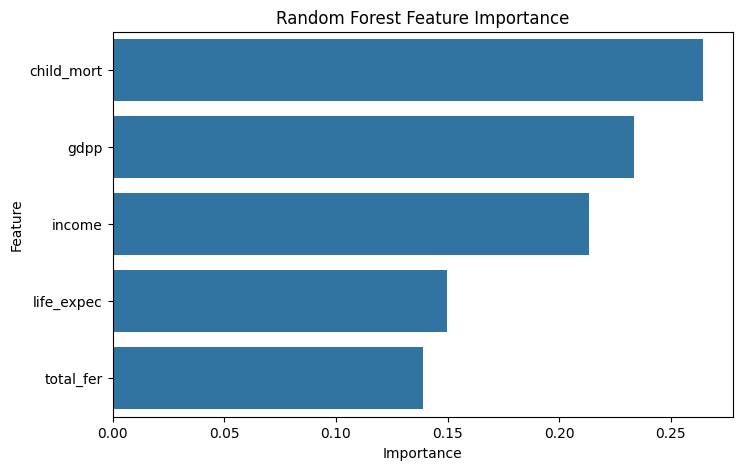

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest Feature Importance")

plt.show()

# Final Conclusion
### Business Insights
The generated country clusters can help HELP International:
- identify high-risk countries
- prioritize aid distribution
- improve healthcare planning
- optimize poverty reduction programs
